In [1]:
# ============================================================
# 1. SETUP, DATA, SPLIT, FEATURES
# ============================================================
import os
os.environ["TABPFN_MAX_BATCHED_TEST_ROWS"] = "1000"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from itertools import combinations
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_poisson_deviance
from sklearn.ensemble import HistGradientBoostingRegressor
from glum import GeneralizedLinearRegressor
from tabpfn import TabPFNClassifier

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#7a7a7a"
SEED = 42

# ---- data: freMTPL2freq from OpenML, with the standard cleaning ----
df = fetch_openml(data_id=41214, as_frame=True).frame
df["ClaimNb"]  = df["ClaimNb"].clip(upper=4)        # a few rows carry implausible counts
df["Exposure"] = df["Exposure"].clip(upper=1)       # a few rows exceed one year
CATS    = ["Area", "VehBrand", "VehGas", "Region"]
FACTORS = ["Area", "VehPower", "VehAge", "DrivAge", "BonusMalus", "VehBrand", "VehGas", "Density", "Region"]
for c in CATS:
    df[c] = df[c].astype(str).str.strip("'").astype("category")   # OpenML sometimes wraps levels in quotes

# ---- split: decided once, never touched again ----
u = np.random.default_rng(SEED).random(len(df))
train      = df[u < .55].copy()                   # every model learns here, and only here
validation = df[(u >= .55) & (u < .80)].copy()    # models are compared here; recommendations come from here
test       = df[u >= .80].copy()                  # locked until the end; used only to score GLM refits

# ---- features ----
# (a) the tutorial GLM's feature engineering (Noll, Salzmann & Wüthrich; actuarial-data-science notebook, model GLM1)
# (b) fine decile bands on the two ages, used only to lay out diagnostic tables
EDGES = {c: np.quantile(train[c], np.linspace(0, 1, 11)) for c in ["DrivAge", "VehAge"]}
for e in EDGES.values(): e[0], e[-1] = -np.inf, np.inf

# fixed category lists so train / validation / test are encoded identically
VEHPOWER_LEVELS = [str(p) for p in range(4, 10)]                                    # 4..8, 9+
VEHAGE_LEVELS   = ["0", "1-10", "11+"]
DRIVAGE_LEVELS  = ["18-20", "21-25", "26-30", "31-40", "41-50", "51-70", "71+"]

def add_features(part):
    part = part.copy()
    part["VehPowerC"]  = pd.Categorical(np.minimum(part.VehPower, 9).astype(int).astype(str), categories=VEHPOWER_LEVELS)
    part["VehAgeC"]    = pd.cut(part.VehAge,  [-np.inf, 1, 11, np.inf], right=False, labels=VEHAGE_LEVELS)
    part["DrivAgeC"]   = pd.cut(part.DrivAge, [-np.inf, 21, 26, 31, 41, 51, 71, np.inf], right=False, labels=DRIVAGE_LEVELS)
    part["BMcap"]      = np.minimum(part.BonusMalus, 150)
    part["AreaN"]      = part.Area.astype(str).map({"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6})
    part["LogDensity"] = np.log(part.Density)
    for c, e in EDGES.items():
        part[c + "Band"] = pd.cut(part[c], bins=np.unique(e), right=False)
    assert part[["VehPowerC", "VehAgeC", "DrivAgeC", "AreaN", "LogDensity"]].notna().all().all(), "feature mapping produced NaNs"
    return part

train, validation, test = add_features(train), add_features(validation), add_features(test)

GLM_COLS = ["VehPowerC", "VehAgeC", "DrivAgeC", "BMcap", "VehBrand", "VehGas", "LogDensity", "Region", "AreaN"]

for name, part in [("train", train), ("validation", validation), ("test", test)]:
    print(f"{name:11s} rows={len(part):7d}  exposure={part.Exposure.sum():9.0f}  claims={part.ClaimNb.sum():6.0f}  "
          f"frequency={part.ClaimNb.sum() / part.Exposure.sum():.4f}")

c:\Users\igode\Desktop\lqm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train       rows= 373336  exposure=   197322  claims= 19899  frequency=0.1008
validation  rows= 169259  exposure=    89551  claims=  8978  frequency=0.1003
test        rows= 135418  exposure=    71488  claims=  7179  frequency=0.1004


In [2]:
# ============================================================
# 3. SCORING  (everything on the frequency scale: claims per exposure-year, exposure-weighted)
# ============================================================
base_rate = train.ClaimNb.sum() / train.Exposure.sum()
_trapz = getattr(np, "trapezoid", None) or np.trapz      # numpy <2 only has trapz

def freq_dev(freq, part):
    """Exposure-weighted Poisson deviance of predicted frequency vs. observed frequency ClaimNb/Exposure."""
    y, e = part.ClaimNb.values, part.Exposure.values
    return mean_poisson_deviance(y / e, np.clip(freq, 1e-6, None), sample_weight=e)

def dev(freq, part):
    return freq_dev(freq, part)

def dev_per_policy(freq, part):
    """Exposure-weighted Poisson deviance averaged per policy (Deprez et al. Table 1 convention).
    Equals the count deviance / number of policies; our `dev` is the same total / total exposure."""
    y, e = part.ClaimNb.values, part.Exposure.values
    return mean_poisson_deviance(y, np.clip(np.asarray(freq) * e, 1e-9, None))

def d2(freq, part):
    """Deviance explained vs. the mean model (charge everyone the portfolio frequency)."""
    return 1 - freq_dev(freq, part) / freq_dev(np.full(len(part), base_rate), part)

def gini(freq, part, seed=0):
    """Ordered Lorenz curve: policies ranked by predicted frequency, cumulative exposure vs. cumulative claims."""
    y, w = part.ClaimNb.values, part.Exposure.values
    perm = np.random.default_rng(seed).permutation(len(y))
    order = perm[np.argsort(np.asarray(freq)[perm], kind="stable")]
    cum_w, cum_y = np.cumsum(w[order]) / w.sum(), np.cumsum(y[order]) / y.sum()
    return 1 - 2 * _trapz(cum_y, cum_w)

def paired_bootstrap(freq_a, freq_b, part, n=500, seed=0):
    """Distribution of the D2 gain of b over a, in percentage points, resampling policies."""
    rng = np.random.default_rng(seed)
    y, e = part.ClaimNb.values, part.Exposure.values
    f, a, b = y / e, np.clip(np.asarray(freq_a), 1e-6, None), np.clip(np.asarray(freq_b), 1e-6, None)
    gains = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        dm = mean_poisson_deviance(f[i], np.full(len(i), base_rate), sample_weight=e[i])
        gains.append((mean_poisson_deviance(f[i], a[i], sample_weight=e[i])
                      - mean_poisson_deviance(f[i], b[i], sample_weight=e[i])) / dm * 100)
    return np.mean(gains), np.percentile(gains, 2.5), np.percentile(gains, 97.5)

def report(name, freq, part):
    """`part` is required on purpose: every score says which split it came from."""
    pred_claims = np.sum(np.asarray(freq) * part.Exposure.values)
    print(f"{name:34s} D2 {d2(freq, part):6.2%}   Gini {gini(freq, part):.3f}   "
          f"dev/yr {dev(freq, part):.4f}   dev/policy {dev_per_policy(freq, part):.4f}   "
          f"predicted claims {pred_claims:6.0f}  (actual {part.ClaimNb.sum():.0f})")

In [3]:
# ============================================================
# 4. THE BASELINE GLM (tutorial specification) AND A GBM CEILING
# ============================================================
FORMULA0 = "C(VehPowerC) + C(VehAgeC) + C(DrivAgeC) + BMcap + C(VehBrand) + C(VehGas) + LogDensity + C(Region) + AreaN"

def fit_glm(formula, data):
    return GeneralizedLinearRegressor(family="poisson", alpha=0, formula=formula, drop_first=True
                                      ).fit(data, data.ClaimNb, offset=np.log(data.Exposure))

def glm_freq(g, part):
    """Predicted frequency: predicting with a zero offset gives exp(x'beta), i.e. claims per exposure-year."""
    return np.asarray(g.predict(part, offset=np.zeros(len(part))))

glm0 = fit_glm(FORMULA0, train)

# a flexible model on the same nine factors: how much structure is there that a GLM's shape could miss?
gbm = HistGradientBoostingRegressor(loss="poisson", max_iter=1000, learning_rate=0.05,
                                    min_samples_leaf=200, categorical_features="from_dtype",
                                    early_stopping=True, validation_fraction=0.1, n_iter_no_change=30,
                                    random_state=0)
gbm.fit(train[FACTORS], train.ClaimNb / train.Exposure, sample_weight=train.Exposure)
gbm_freq = lambda part: gbm.predict(part[FACTORS])
print(f"GBM stopped after {gbm.n_iter_} rounds")

# models are compared on validation; test stays locked for the final GLM refits
report("mean model",              np.full(len(validation), base_rate), validation)
report("GLM0  (tutorial spec)",   glm_freq(glm0, validation),          validation)
report("GBM   (ceiling)",         gbm_freq(validation),                validation)
print(f"\nGLM0 has {len(glm0.coef_)} parameters")

GBM stopped after 139 rounds
mean model                         D2  0.00%   Gini 0.008   dev/yr 0.6214   dev/policy 0.3287   predicted claims   9031  (actual 8978)
GLM0  (tutorial spec)              D2  4.92%   Gini 0.279   dev/yr 0.5908   dev/policy 0.3126   predicted claims   9037  (actual 8978)
GBM   (ceiling)                    D2  8.15%   Gini 0.332   dev/yr 0.5707   dev/policy 0.3019   predicted claims   9035  (actual 8978)

GLM0 has 48 parameters


In [8]:
# ============================================================
# 5. THE INFORMANT: a TabPFN classifier on the nine rating factors, no exposure feature,
#    recalibrated to a claim frequency with a Poisson GLM and log-exposure offset
# ============================================================
# ---- context (what TabPFN learns from) and calibration rows (never in its context), both from train ----
ctx   = train.groupby(train.ClaimNb > 0, group_keys=False).sample(frac=100_000 / len(train), random_state=0)
calib = train.drop(ctx.index).sample(80_000, random_state=0)
k2    = ctx.loc[ctx.ClaimNb >= 2, "ClaimNb"].mean()          # average count among 2+ rows

# ---- inputs: the nine factors only; categoricals as integer codes, declared to TabPFN ----
LQM_INPUTS = FACTORS
CAT_IDX    = [LQM_INPUTS.index(c) for c in CATS]

def lqm_inputs(part):
    X = part[LQM_INPUTS].copy()
    for c in CATS:
        X[c] = X[c].cat.codes
    return X

_lqm = None
def lqm_model():
    """Fit TabPFN at most once per session, and only if some prediction is not on disk."""
    global _lqm
    if _lqm is None:
        m = TabPFNClassifier(device="cuda", random_state=0, fit_mode="fit_with_cache", n_estimators=4,
                             categorical_features_indices=CAT_IDX)
        _lqm = m.fit(lqm_inputs(ctx), np.minimum(ctx.ClaimNb.values, 2))       # classes 0 / 1 / 2+
    return _lqm

def lqm_raw(part, name, chunk=5000):
    """Raw expected claims per policy (term averaged out): P(1) + k2 * P(2+).
    Class probabilities cached on disk; delete the file if SEED, the split, or the context sample changes."""
    path = f"lqm_noexp_{name}.parquet"
    if os.path.exists(path):
        P = pd.read_parquet(path).loc[part.index].values
    else:
        X = lqm_inputs(part)
        P = np.vstack([lqm_model().predict_proba(X.iloc[i:i + chunk]) for i in range(0, len(X), chunk)])
        pd.DataFrame(P, index=part.index, columns=["p0", "p1", "p2"]).to_parquet(path)
    return P[:, 1] + k2 * P[:, 2]

def recalibrate(raw_cal):
    """Poisson GLM with log-exposure offset on the calibration rows:
       E[ClaimNb] = Exposure * exp(a + b * log(raw))   =>   frequency = exp(a + b * log(raw))"""
    x = np.log(np.clip(raw_cal, 1e-9, None)).reshape(-1, 1)
    g = GeneralizedLinearRegressor(family="poisson", alpha=0).fit(x, calib.ClaimNb, offset=np.log(calib.Exposure))
    a, b = g.intercept_, g.coef_[0]
    return a, b, (lambda raw: np.exp(a + b * np.log(np.clip(raw, 1e-9, None))))

def calibration_table(part, by, cols):
    """Per decile of `by`: exposure, claims, observed frequency = claims/exposure, then A/E and deviance per model."""
    g = part.groupby(pd.qcut(part[by], 10, labels=False, duplicates="drop"))
    out = {"exposure": g.Exposure.sum(), "claims": g.ClaimNb.sum()}
    out["observed freq"] = out["claims"] / out["exposure"]
    for lab, col in cols.items():
        pred_claims = g.apply(lambda d: (d[col] * d.Exposure).sum(), include_groups=False)
        out[f"pred freq {lab}"] = pred_claims / out["exposure"]
        out[f"A/{lab}"]         = out["claims"] / pred_claims
        out[f"dev {lab}"]       = g.apply(lambda d: dev(d[col].values, d), include_groups=False)
    return pd.DataFrame(out)

# ---- predict, then recalibrate on rows TabPFN never saw ----
raw_cal = lqm_raw(calib, "calib")
raw_val = lqm_raw(validation, "validation")
a, b, lqm_freq = recalibrate(raw_cal)
print(f"recalibration: frequency = exp({a:.3f} + {b:.3f} * log(raw))   "
      f"[raw total on calib was {(raw_cal * calib.Exposure.values).sum() / calib.ClaimNb.sum():.0%} of actual claims; "
      f"below 100% by construction, since raw is per policy and the offset rescales it to per year]")

validation["glm_freq"] = glm_freq(glm0, validation)
validation["lqm_raw"]  = raw_val                     # TabPFN as-is: expected claims per policy, not a frequency
validation["lqm_freq"] = lqm_freq(raw_val)           # claims per exposure-year
validation["gbm_freq"] = gbm_freq(validation)

# ---- validation: level, ranking, deviance, calibration across the risk spectrum ----
# The raw row is TabPFN as-is (expected claims per policy, not a frequency): its level, D2 and deviance are off by
# construction, but its Gini equals the recalibrated Gini, showing that the ranking comes entirely from TabPFN.
print("\nvalidation scores:")
report("GLM0  (tutorial spec)",    validation.glm_freq.values, validation)
report("LQM   raw (uncalibrated)", validation.lqm_raw.values,  validation)
report("LQM   (recalibrated)",     validation.lqm_freq.values, validation)
report("GBM   (ceiling)",          validation.gbm_freq.values, validation)

m, lo, hi = paired_bootstrap(validation.glm_freq.values, validation.lqm_freq.values, validation)
print(f"\nD2 gain of LQM over GLM0: {m:+.2f} pp   95% interval [{lo:+.2f}, {hi:+.2f}]")

print("\nby decile of LQM-predicted frequency  (A/E: 1.0 everywhere = calibrated;  dev: exposure-weighted Poisson deviance, lower is better):")
print(calibration_table(validation, "lqm_freq", {"LQM": "lqm_freq", "GLM0": "glm_freq"}).round(4).T)
print("\nby decile of GLM0-predicted frequency:")
print(calibration_table(validation, "glm_freq", {"GLM0": "glm_freq", "LQM": "lqm_freq"}).round(4).T)

# ---- exposure bands: neither model sees the term, so compare ranking (Gini) within each band ----
for lab, mask in [("exposure < 0.25", validation.Exposure < 0.25), ("exposure >= 0.25", validation.Exposure >= 0.25)]:
    sub = validation[mask]
    print(f"\n{lab}: {len(sub)} policies")
    report("   LQM  raw (uncalibrated)", sub.lqm_raw.values,  sub)
    report("   LQM  (recalibrated)",     sub.lqm_freq.values, sub)
    report("   GLM0",                    sub.glm_freq.values, sub)

recalibration: frequency = exp(1.155 + 1.062 * log(raw))   [raw total on calib was 38% of actual claims; below 100% by construction, since raw is per policy and the offset rescales it to per year]

validation scores:
GLM0  (tutorial spec)              D2  4.92%   Gini 0.279   dev/yr 0.5908   dev/policy 0.3126   predicted claims   9037  (actual 8978)
LQM   raw (uncalibrated)           D2 -4.37%   Gini 0.290   dev/yr 0.6485   dev/policy 0.3431   predicted claims   3468  (actual 8978)
LQM   (recalibrated)               D2  6.53%   Gini 0.290   dev/yr 0.5808   dev/policy 0.3073   predicted claims   9097  (actual 8978)
GBM   (ceiling)                    D2  8.15%   Gini 0.332   dev/yr 0.5707   dev/policy 0.3019   predicted claims   9035  (actual 8978)

D2 gain of LQM over GLM0: +1.58 pp   95% interval [+1.19, +2.02]

by decile of LQM-predicted frequency  (A/E: 1.0 everywhere = calibrated;  dev: exposure-weighted Poisson deviance, lower is better):
lqm_freq                0          1       

In [21]:
# ============================================================
# 8. EXPORT: summary scores and A/E by decile for GLM0, LQM classifier, LQM regressor  ->  csv
# ============================================================
MODELS = {"GLM0":                      "glm_freq",
          "LQM classifier raw":        "lqm_raw",     # before calibration: expected claims per policy, not a frequency
          "LQM classifier calibrated": "lqm_freq",
          "LQM regressor raw":         "reg_raw",
          "LQM regressor calibrated":  "reg_freq"}
part = validation

# ---- summary scores ----
summary = pd.DataFrame([{
    "model":                      name,
    "split":                      "validation",
    "deviance R2":                d2(part[col].values, part),
    "Poisson deviance per policy": dev_per_policy(part[col].values, part),
    "Poisson deviance per exposure-year": dev(part[col].values, part),
    "Gini":                       gini(part[col].values, part),
    "predicted claims":           float(np.sum(part[col].values * part.Exposure.values)),
    "actual claims":              float(part.ClaimNb.sum()),
} for name, col in MODELS.items()])
summary.to_csv("model_scores_validation.csv", index=False)

# ---- A/E by decile of each model's own predicted frequency ----
rows = []
for name, col in MODELS.items():
    dec = pd.qcut(part[col], 10, labels=False, duplicates="drop")
    g = part.groupby(dec, observed=True)
    exposure   = g.Exposure.sum()
    claims     = g.ClaimNb.sum()
    pred_claim = g.apply(lambda s: (s[col] * s.Exposure).sum(), include_groups=False)
    for k in exposure.index:
        rows.append({"model": name, "decile": int(k) + 1,
                     "exposure-years": exposure[k], "claims": claims[k],
                     "observed frequency": claims[k] / exposure[k],
                     "predicted frequency": pred_claim[k] / exposure[k],
                     "A/E": claims[k] / pred_claim[k]})
deciles = pd.DataFrame(rows)
deciles.to_csv("model_ae_by_decile_validation.csv", index=False)

print(summary.round(4).to_string(index=False))
print()
print(deciles.pivot(index="decile", columns="model", values="A/E").round(3).to_string())
print("\nwritten: model_scores_validation.csv, model_ae_by_decile_validation.csv")

                    model      split  deviance R2  Poisson deviance per policy  Poisson deviance per exposure-year   Gini  predicted claims  actual claims
                     GLM0 validation       0.0492                       0.3126                              0.5908 0.2791         9037.1923         8978.0
       LQM classifier raw validation      -0.0437                       0.3431                              0.6485 0.2903         3467.7764         8978.0
LQM classifier calibrated validation       0.0653                       0.3073                              0.5808 0.2903         9096.7875         8978.0
        LQM regressor raw validation      -0.3289                       0.4369                              0.8257 0.2923         1181.2305         8978.0
 LQM regressor calibrated validation       0.0566                       0.3101                              0.5862 0.2923         9085.2045         8978.0

model    GLM0  LQM classifier calibrated  LQM classifier raw  LQM reg

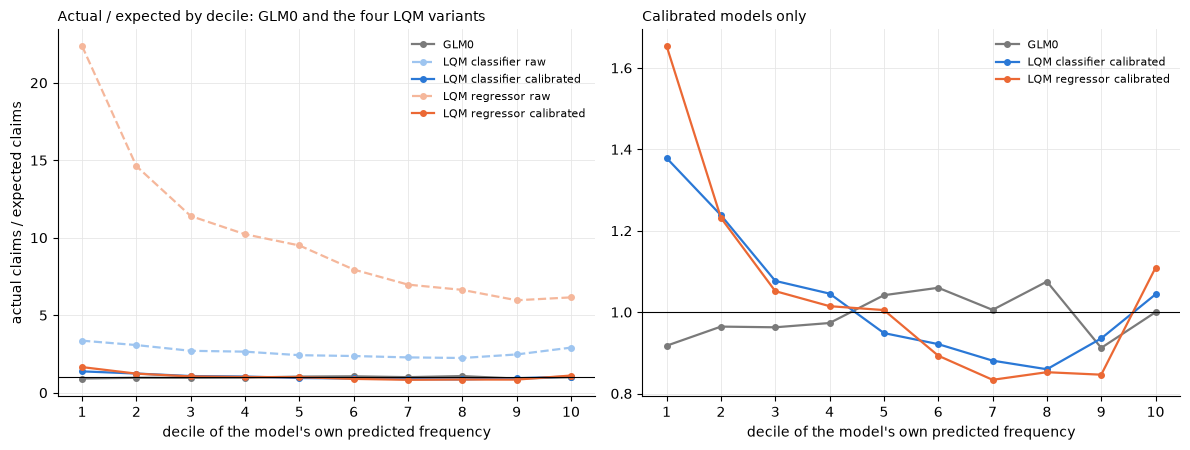

In [24]:
# ============================================================
# 9. A/E BY DECILE, LINE PLOT: GLM0 and the four LQM variants (each model on its own deciles, validation)
# ============================================================
d = deciles[deciles.split == "validation"] if "split" in deciles else deciles
ORDER  = ["GLM0", "LQM classifier raw", "LQM classifier calibrated", "LQM regressor raw", "LQM regressor calibrated"]
COLOUR = {"GLM0": GREY, "LQM classifier raw": "#9ec5f0", "LQM classifier calibrated": BLUE,
          "LQM regressor raw": "#f5b79b", "LQM regressor calibrated": ORANGE}
STYLE  = {m: ("--" if m.endswith("raw") else "-") for m in ORDER}

def ae_panel(ax, models, title):
    for m in models:
        s = d[d.model == m].sort_values("decile")
        ax.plot(s.decile, s["A/E"], STYLE[m], color=COLOUR[m], lw=1.6, marker="o", ms=4, label=m)
    ax.axhline(1, color="black", lw=0.8)
    ax.set_xticks(range(1, 11)); ax.set_xlabel("decile of the model's own predicted frequency")
    ax.set_title(title, fontsize=10, loc="left")
    ax.grid(True, color="#e6e6e6", lw=0.6); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ae_panel(axes[0], ORDER, "Actual / expected by decile: GLM0 and the four LQM variants")
ae_panel(axes[1], ["GLM0", "LQM classifier calibrated", "LQM regressor calibrated"], "Calibrated models only")
axes[0].set_ylabel("actual claims / expected claims")
plt.tight_layout(); plt.show()

       mean LQM/GLM0  exposure  claims  observed freq  A/GLM0  A/LQM
ratio                                                               
0              0.328    5319.0     525          0.099   0.469  1.559
1              0.505    6952.0     585          0.084   0.700  1.393
2              0.637    7544.0     656          0.087   0.805  1.264
3              0.761    8225.0     774          0.094   0.929  1.223
4              0.880    8816.0     798          0.091   0.958  1.089
5              0.992    9607.0     904          0.094   1.050  1.058
6              1.105   10257.0     887          0.086   0.999  0.904
7              1.232   10748.0     972          0.090   1.067  0.866
8              1.410   11356.0    1066          0.094   1.132  0.802
9              2.130   10727.0    1811          0.169   1.811  0.835


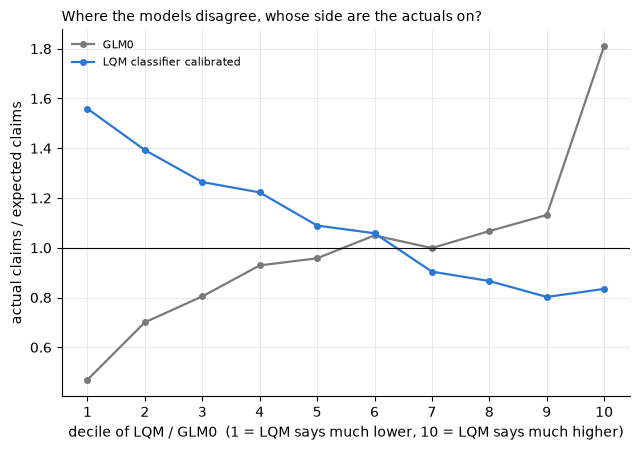

In [34]:
# A/E by decile of the disagreement ratio LQM/GLM0: symmetric binning, actual claims as the judge
d = validation.copy()
d["ratio"] = d.lqm_freq / d.glm_freq
dec = pd.qcut(d.ratio, 10, labels=False)
g = d.groupby(dec, observed=True)
tab = pd.DataFrame({"mean LQM/GLM0": g.apply(lambda s: np.average(s.ratio, weights=s.Exposure), include_groups=False),
                    "exposure": g.Exposure.sum().round(0), "claims": g.ClaimNb.sum(),
                    "observed freq": g.ClaimNb.sum() / g.Exposure.sum()})
for name, col in [("GLM0", "glm_freq"), ("LQM", "lqm_freq")]:
    tab[f"A/{name}"] = g.ClaimNb.sum() / g.apply(lambda s: (s[col] * s.Exposure).sum(), include_groups=False)
print(tab.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.plot(tab.index + 1, tab["A/GLM0"], "-o", color=GREY, lw=1.6, ms=4, label="GLM0")
ax.plot(tab.index + 1, tab["A/LQM"],  "-o", color=BLUE, lw=1.6, ms=4, label="LQM classifier calibrated")
ax.axhline(1, color="black", lw=0.8)
ax.set_xticks(range(1, 11)); ax.set_xlabel("decile of LQM / GLM0  (1 = LQM says much lower, 10 = LQM says much higher)")
ax.set_ylabel("actual claims / expected claims"); ax.set_title("Where the models disagree, whose side are the actuals on?", fontsize=10, loc="left")
ax.grid(True, color="#e6e6e6", lw=0.6); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

In [32]:
# ============================================================
# 5f. IS THE RECALIBRATION OVERFITTED?  Refit the map on disjoint halves and on bootstrap draws of the calibration rows
# ============================================================
rows = []
perm = np.random.default_rng(0).permutation(len(calib))
half = np.zeros(len(calib), bool); half[perm[:len(calib) // 2]] = True
for lab, mask in [("all calibration rows", np.ones(len(calib), bool)), ("half A", half), ("half B", ~half)]:
    c = calib[mask]
    x = np.log(np.clip(raw_cal[mask], 1e-9, None)).reshape(-1, 1)
    g = GeneralizedLinearRegressor(family="poisson", alpha=0).fit(x, c.ClaimNb, offset=np.log(c.Exposure))
    f = np.exp(g.intercept_ + g.coef_[0] * np.log(np.clip(raw_val, 1e-9, None)))
    rows.append({"fitted on": lab, "rows": int(mask.sum()), "a": g.intercept_, "b": g.coef_[0],
                 "validation D2": d2(f, validation), "validation Gini": gini(f, validation),
                 "validation predicted claims": float(np.sum(f * validation.Exposure.values))})
print(pd.DataFrame(rows).round(4).to_string(index=False))

# bootstrap the calibration rows: spread of a, b, and validation D2 across 200 resamples
rng = np.random.default_rng(1)
ab, d2s = [], []
for _ in range(200):
    i = rng.integers(0, len(calib), len(calib))
    c = calib.iloc[i]
    x = np.log(np.clip(raw_cal[i], 1e-9, None)).reshape(-1, 1)
    g = GeneralizedLinearRegressor(family="poisson", alpha=0).fit(x, c.ClaimNb, offset=np.log(c.Exposure))
    ab.append((g.intercept_, g.coef_[0]))
    d2s.append(d2(np.exp(g.intercept_ + g.coef_[0] * np.log(np.clip(raw_val, 1e-9, None))), validation))
ab = np.array(ab)
print(f"\nbootstrap over calibration rows (200 draws):  a = {ab[:,0].mean():.3f} ± {ab[:,0].std():.3f}   "
      f"b = {ab[:,1].mean():.3f} ± {ab[:,1].std():.3f}   validation D2 = {np.mean(d2s):.2%} ± {np.std(d2s):.2%}")

           fitted on  rows      a      b  validation D2  validation Gini  validation predicted claims
all calibration rows 80000 1.1545 1.0622         0.0653           0.2903                    9096.7875
              half A 40000 1.1427 1.0581         0.0653           0.2903                    9104.4529
              half B 40000 1.1667 1.0665         0.0653           0.2903                    9089.2667

bootstrap over calibration rows (200 draws):  a = 1.151 ± 0.073   b = 1.062 ± 0.024   validation D2 = 6.52% ± 0.01%


In [19]:
# ============================================================
# 4b. THREE SPELLINGS OF THE SAME FREQUENCY GLM
# ============================================================
from sklearn.linear_model import PoissonRegressor
from formulaic import model_matrix

# (1) counts + log-exposure offset  (what fit_glm does)
g_off = fit_glm(FORMULA0, train)

# (2) frequency target + exposure weight, same library, same design matrix
g_wt = GeneralizedLinearRegressor(family="poisson", alpha=0, formula=FORMULA0, drop_first=True
                                  ).fit(train, train.ClaimNb / train.Exposure, sample_weight=train.Exposure)

# (3) frequency target + exposure weight in scikit-learn, as in the lab (no offset argument exists there)
X_tr = model_matrix(FORMULA0, train, ensure_full_rank=True).drop(columns="Intercept")
X_va = model_matrix(FORMULA0, validation, ensure_full_rank=True).drop(columns="Intercept")[X_tr.columns]
g_sk = PoissonRegressor(alpha=1e-4, max_iter=2000, tol=1e-8).fit(X_tr, train.ClaimNb / train.Exposure,
                                                                  sample_weight=train.Exposure)
g_sk0 = PoissonRegressor(alpha=0, max_iter=2000, tol=1e-8).fit(X_tr, train.ClaimNb / train.Exposure,
                                                                sample_weight=train.Exposure)

f_off, f_wt = glm_freq(g_off, validation), g_wt.predict(validation)
f_sk, f_sk0 = g_sk.predict(X_va), g_sk0.predict(X_va)

print(f"(1) vs (2), glum offset vs glum weights:      max |coef diff| {np.abs(g_off.coef_ - g_wt.coef_).max():.2e}   "
      f"max |freq diff| {np.abs(f_off - f_wt).max():.2e}")
print(f"(1) vs (3), glum offset vs sklearn alpha=1e-4: max |freq diff| {np.abs(f_off - f_sk).max():.2e}   "
      f"(small ridge penalty, so not identical)")
print(f"(1) vs (3'), glum offset vs sklearn alpha=0:   max |freq diff| {np.abs(f_off - f_sk0).max():.2e}\n")

report("counts + offset  (glum)",        f_off, validation)
report("frequency + weight (glum)",      f_wt,  validation)
report("frequency + weight (sklearn)",   f_sk,  validation)
report("frequency + weight (sklearn, alpha=0)", f_sk0, validation)

(1) vs (2), glum offset vs glum weights:      max |coef diff| 7.23e-14   max |freq diff| 1.32e-13
(1) vs (3), glum offset vs sklearn alpha=1e-4: max |freq diff| 1.90e-01   (small ridge penalty, so not identical)
(1) vs (3'), glum offset vs sklearn alpha=0:   max |freq diff| 8.36e-04

counts + offset  (glum)            D2  4.92%   Gini 0.279   dev/yr 0.5908   dev/policy 0.3126   predicted claims   9037  (actual 8978)
frequency + weight (glum)          D2  4.92%   Gini 0.279   dev/yr 0.5908   dev/policy 0.3126   predicted claims   9037  (actual 8978)
frequency + weight (sklearn)       D2  4.94%   Gini 0.279   dev/yr 0.5907   dev/policy 0.3125   predicted claims   9035  (actual 8978)
frequency + weight (sklearn, alpha=0) D2  4.92%   Gini 0.279   dev/yr 0.5908   dev/policy 0.3126   predicted claims   9036  (actual 8978)


In [35]:
# ============================================================
# 7. DERIVING A RECOMMENDATION FROM THE INFORMANT
# Disagreement d = log(LQM / GLM0) per policy. Rank single factors by how much of d they explain (shape / banding),
# then pairs by how much their interaction explains beyond the two main effects. Verify the top candidates against
# actual claims, then refit the GLM with one added term and score it on validation.
# ============================================================
DENS_EDGES = np.quantile(np.log(train.Density), np.linspace(0, 1, 11)); DENS_EDGES[0], DENS_EDGES[-1] = -np.inf, np.inf

def add_scan_bands(part):
    part = part.copy()
    part["BM_b"]     = pd.cut(part.BonusMalus, [0, 51, 55, 60, 70, 80, 90, 100, 120, 150, 999], right=False)
    part["DrivAge_b"]= pd.cut(part.DrivAge,   [0, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 200], right=False)
    part["VehAge_b"] = pd.cut(part.VehAge,    [0, 1, 2, 3, 6, 11, 16, 200], right=False)
    part["VehPow_b"] = pd.Categorical(np.minimum(part.VehPower, 12).astype(int))
    part["Dens_b"]   = pd.cut(np.log(part.Density), np.unique(DENS_EDGES), right=False)
    part["Area_b"], part["Brand_b"], part["Gas_b"], part["Region_b"] = part.Area, part.VehBrand, part.VehGas, part.Region
    return part

SCAN = ["BM_b", "DrivAge_b", "VehAge_b", "VehPow_b", "Dens_b", "Area_b", "Brand_b", "Gas_b", "Region_b"]
train, validation, test = add_scan_bands(train), add_scan_bands(validation), add_scan_bands(test)

v = validation
w = v.Exposure.values
d = np.log(v.lqm_freq.values / v.glm_freq.values)
grand = np.average(d, weights=w)
total_var = np.average((d - grand) ** 2, weights=w)

def wmean_by(keys):
    """Exposure-weighted mean of d within each cell of `keys`, broadcast back to policies."""
    g = pd.DataFrame({"d_w": d * w, "w": w, **{k: v[k].values for k in keys}}).groupby(keys, observed=True)
    m = (g.d_w.sum() / g.w.sum())
    return v[keys].merge(m.rename("m").reset_index(), on=keys, how="left")["m"].values, m

# ---- (1) single factors: share of disagreement explained  ->  shape / banding candidates ----
rows = []
for f in SCAN:
    fitted, _ = wmean_by([f])
    rows.append({"factor": f, "levels": v[f].nunique(),
                 "share of disagreement explained": np.average((fitted - grand) ** 2, weights=w) / total_var})
single = pd.DataFrame(rows).sort_values("share of disagreement explained", ascending=False).reset_index(drop=True)
print("(1) single factors ranked by how much of log(LQM/GLM0) they explain:")
print(single.round(3).to_string(index=False))

# ---- (2) pairs: share explained by the interaction beyond the two main effects  ->  interaction candidates ----
main = {f: wmean_by([f])[0] for f in SCAN}
rows = []
for f1, f2 in combinations(SCAN, 2):
    resid = d - main[f1] - main[f2] + grand                     # remove both main effects
    g = pd.DataFrame({"r_w": resid * w, "w": w, f1: v[f1].values, f2: v[f2].values}).groupby([f1, f2], observed=True)
    cell = (g.r_w.sum() / g.w.sum()).rename("m").reset_index()
    fitted = v[[f1, f2]].merge(cell, on=[f1, f2], how="left")["m"].values
    rows.append({"pair": f"{f1} x {f2}", "cells": len(cell),
                 "share explained by interaction": np.average(fitted ** 2, weights=w) / total_var})
pairs = pd.DataFrame(rows).sort_values("share explained by interaction", ascending=False).reset_index(drop=True)
print("\n(2) pairs ranked by how much of log(LQM/GLM0) their interaction explains beyond the main effects:")
print(pairs.head(8).round(3).to_string(index=False))

# ---- (3) verify the top single factor against actual claims: does A/GLM0 move with the LQM's suggested correction? ----
top = single.factor[0]
g = v.groupby(top, observed=True)
ver = pd.DataFrame({"exposure":     g.Exposure.sum().round(0),
                    "claims":       g.ClaimNb.sum(),
                    "LQM/GLM0":     np.exp(wmean_by([top])[1]),
                    "A/GLM0":       g.ClaimNb.sum() / g.apply(lambda s: (s.glm_freq * s.Exposure).sum(), include_groups=False),
                    "A/LQM":        g.ClaimNb.sum() / g.apply(lambda s: (s.lqm_freq * s.Exposure).sum(), include_groups=False)})
print(f"\n(3) top factor {top}: the LQM's correction to the GLM by level, next to what actual claims say.")
print("    If A/GLM0 tracks LQM/GLM0 and A/LQM stays near 1, the LQM is right and the GLM's term for this factor has the wrong shape.")
print(ver.round(3).to_string())

(1) single factors ranked by how much of log(LQM/GLM0) they explain:
   factor  levels  share of disagreement explained
  Brand_b      11                            0.206
 VehAge_b       7                            0.151
 Region_b      22                            0.116
DrivAge_b      13                            0.102
     BM_b      10                            0.061
   Area_b       6                            0.046
   Dens_b      10                            0.046
 VehPow_b       9                            0.018
    Gas_b       2                            0.001

(2) pairs ranked by how much of log(LQM/GLM0) their interaction explains beyond the main effects:
               pair  cells  share explained by interaction
 VehAge_b x Brand_b     77                           0.136
   BM_b x DrivAge_b    124                           0.064
VehAge_b x Region_b    154                           0.042
    Dens_b x Area_b     15                           0.042
 Brand_b x Region_b    240 

(3b) B12 vs other brands  x  vehicle-age band, validation:
                 exposure  claims  observed freq  GLM0 pred  LQM pred  A/GLM0  A/LQM
B12   VehAge_b                                                                      
B12   [0, 1)       2383.0    1056          0.443      0.340     0.279   1.304  1.588
      [1, 2)       4224.0     317          0.075      0.105     0.061   0.714  1.231
      [2, 3)       2989.0     229          0.077      0.102     0.061   0.748  1.254
      [3, 6)       4137.0     317          0.077      0.105     0.064   0.732  1.194
      [6, 11)      1649.0     168          0.102      0.110     0.084   0.929  1.216
      [11, 16)      508.0      37          0.073      0.090     0.083   0.809  0.879
      [16, 200)     160.0       6          0.037      0.085     0.063   0.442  0.595
other [0, 1)       1739.0     210          0.121      0.288     0.094   0.419  1.289
      [1, 2)       3981.0     409          0.103      0.089     0.112   1.155  0.916
      

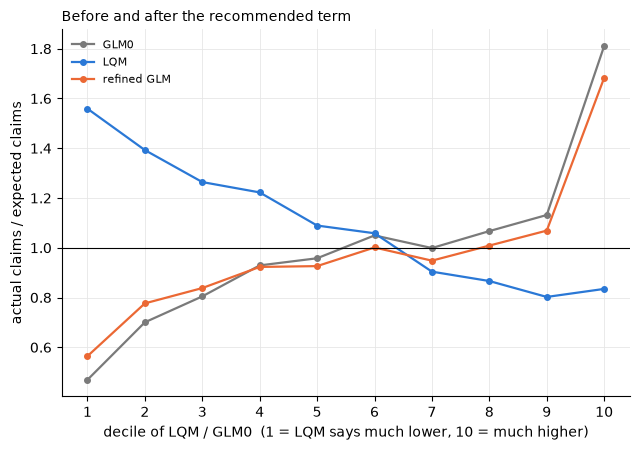

In [37]:
# ============================================================
# 7b. VERIFY THE TOP PAIR AT CELL LEVEL, THEN REFIT THE GLM WITH ONE ADDED TERM
# From (1)-(3): brand and vehicle age explain most of the disagreement, the brand marginals are already right,
# and brand x vehicle age is the top interaction by a factor of two. So the candidate is an interaction, not a banding.
# ============================================================
for part in (train, validation, test):
    part["B12"] = np.where(part.VehBrand.astype(str) == "B12", "B12", "other")
v = validation

# ---- (3b) cell-level check: is the GLM wrong within B12 x vehicle-age cells although the brand marginal is fine? ----
g = v.groupby(["B12", "VehAge_b"], observed=True)
cells = pd.DataFrame({"exposure":      g.Exposure.sum().round(0),
                      "claims":        g.ClaimNb.sum(),
                      "observed freq": g.ClaimNb.sum() / g.Exposure.sum(),
                      "GLM0 pred":     g.apply(lambda s: (s.glm_freq * s.Exposure).sum() / s.Exposure.sum(), include_groups=False),
                      "LQM pred":      g.apply(lambda s: (s.lqm_freq * s.Exposure).sum() / s.Exposure.sum(), include_groups=False)})
cells["A/GLM0"] = cells["observed freq"] / cells["GLM0 pred"]
cells["A/LQM"]  = cells["observed freq"] / cells["LQM pred"]
print("(3b) B12 vs other brands  x  vehicle-age band, validation:")
print(cells.round(3).to_string())

# ---- compact term: B12 x vehicle-age band as explicit deviation dummies ----
# The B12 level inside C(VehBrand) carries the reference band; these columns carry each other band's deviation from it.
# (A formula term C(B12):C(VehAge_b) is collinear with the intercept, VehAgeC and the B12 brand dummy, hence the singular matrix.)
BANDS = list(train.VehAge_b.cat.categories)
REF   = BANDS[3]                                              # [3, 6): a well-populated middle band as reference
INT_COLS = []
for i, band in enumerate(BANDS):
    if band == REF:
        continue
    col = f"b12_va{i}"
    for part in (train, validation, test):
        part[col] = ((part.B12 == "B12") & (part.VehAge_b == band)).astype(float)
    INT_COLS.append(col)
print(f"\ncompact interaction: {len(INT_COLS)} columns, reference band {REF}")

# ---- (4) acceptance: candidate terms added to the tutorial GLM, refit on train, scored on validation ----
def fit_glm_safe(formula, data, alpha=0):
    """fit_glm with an optional numerically-zero ridge, for designs with an empty cell somewhere."""
    return GeneralizedLinearRegressor(family="poisson", alpha=alpha, formula=formula, drop_first=True
                                      ).fit(data, data.ClaimNb, offset=np.log(data.Exposure))

CANDIDATES = {
    "GLM0 (tutorial)":                     (FORMULA0, 0),
    "GLM + B12 x vehicle-age band":        (FORMULA0 + " + " + " + ".join(INT_COLS), 0),
    "GLM + full brand x vehicle-age band": (FORMULA0.replace("C(VehAgeC)", "C(VehAge_b)") + " + C(VehBrand):C(VehAge_b)", 1e-8),
}
cand_fit = {}
print("\n(4) candidates on validation:")
for name, (formula, alpha) in CANDIDATES.items():
    gfit = fit_glm_safe(formula, train, alpha)
    cand_fit[name] = gfit
    validation[f"cand::{name}"] = glm_freq(gfit, validation)
    m, lo, hi = paired_bootstrap(validation.glm_freq.values, validation[f"cand::{name}"].values, validation)
    report(name, validation[f"cand::{name}"].values, validation)
    print(f"{'':34s} parameters {len(gfit.coef_) + 1:4d}   D2 gain over GLM0 {m:+.2f} pp  [{lo:+.2f}, {hi:+.2f}]\n")

# ---- (5) did the refinement fix what the informant pointed at?  A/E across the disagreement deciles, before and after ----
RECOMMENDED = "GLM + B12 x vehicle-age band"
v["ratio"] = v.lqm_freq / v.glm_freq
dec = pd.qcut(v.ratio, 10, labels=False)
g = v.groupby(dec, observed=True)
ae = pd.DataFrame({name: g.ClaimNb.sum() / g.apply(lambda s: (s[col] * s.Exposure).sum(), include_groups=False)
                   for name, col in [("GLM0", "glm_freq"), ("LQM", "lqm_freq"), ("refined GLM", f"cand::{RECOMMENDED}")]})
print("(5) A/E by decile of LQM/GLM0 disagreement:")
print(ae.round(3).T.to_string())

fig, ax = plt.subplots(figsize=(6.5, 4.6))
for name, colour in [("GLM0", GREY), ("LQM", BLUE), ("refined GLM", ORANGE)]:
    ax.plot(ae.index + 1, ae[name], "-o", color=colour, lw=1.6, ms=4, label=name)
ax.axhline(1, color="black", lw=0.8)
ax.set_xticks(range(1, 11)); ax.set_xlabel("decile of LQM / GLM0  (1 = LQM says much lower, 10 = much higher)")
ax.set_ylabel("actual claims / expected claims"); ax.set_title("Before and after the recommended term", fontsize=10, loc="left")
ax.grid(True, color="#e6e6e6", lw=0.6); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

In [38]:
# ============================================================
# 7c. THE TEST READ: GLM0 vs the refined GLM on policies no model or decision has touched
# ============================================================
test["glm_freq"] = glm_freq(glm0, test)
test["glm_ref"]  = glm_freq(cand_fit[RECOMMENDED], test)
report("GLM0 (tutorial)   [test]", test.glm_freq.values, test)
report(f"{RECOMMENDED}   [test]", test.glm_ref.values, test)
m, lo, hi = paired_bootstrap(test.glm_freq.values, test.glm_ref.values, test)
print(f"\ntest: D2 gain of the refined GLM over GLM0 {m:+.2f} pp   95% interval [{lo:+.2f}, {hi:+.2f}]")

GLM0 (tutorial)   [test]           D2  5.01%   Gini 0.276   dev/yr 0.5868   dev/policy 0.3098   predicted claims   7253  (actual 7179)
GLM + B12 x vehicle-age band   [test] D2  5.74%   Gini 0.284   dev/yr 0.5823   dev/policy 0.3074   predicted claims   7248  (actual 7179)

test: D2 gain of the refined GLM over GLM0 +0.73 pp   95% interval [+0.57, +0.87]


y-axis: validation bins pool to 8978 claims / 89551 exposure-years = 0.1003  (validation overall 0.1003)
x-axis, left : raw per policy, exposure-weighted mean 0.0387 vs calib observed frequency 0.1014  (gap = level correction)
x-axis, right: recalibrated frequency, predicted claims 9097 vs actual 8978


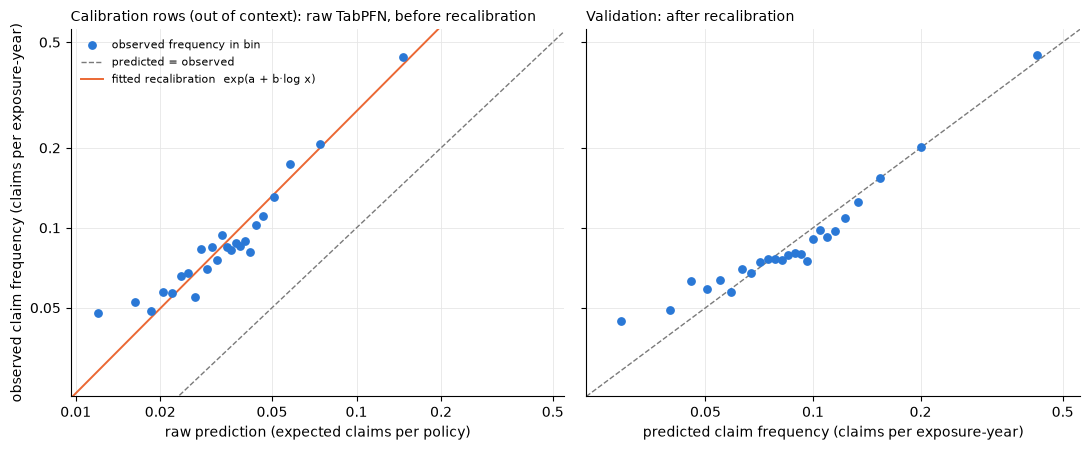


before: raw bins vs their own straight line — slope 0.924 (recalibration b = 1.062), log-residual sd 0.149, largest |residual| 0.354
after:  validation actual/predicted by bin ranges 0.78 – 1.54; bins outside ±10%: 11 of 25


In [16]:
# ============================================================
# 5b. BEFORE AND AFTER RECALIBRATION: binned predicted vs observed claim frequency, log-log
# y on both panels: observed claim frequency = claims / exposure within the bin (claims per exposure-year)
# x left:  raw TabPFN prediction (expected claims per policy)     -> off the identity by design; the orange line is the fitted map
# x right: recalibrated frequency (claims per exposure-year)      -> should sit on the identity
# ============================================================
def freq_bins(pred, part, n_bins=25):
    """Equal-exposure bins of the prediction. Within each bin:
       pred   = exposure-weighted mean of the prediction
       actual = sum(ClaimNb) / sum(Exposure)          <- claim frequency, claims per exposure-year
       se     = sqrt(sum(ClaimNb)) / sum(Exposure)    <- Poisson standard error of that frequency"""
    d = pd.DataFrame({"pred": np.asarray(pred, dtype=float),
                      "y":    part.ClaimNb.values.astype(float),
                      "e":    part.Exposure.values.astype(float)}).sort_values("pred")
    d["bin"] = pd.cut(d.e.cumsum(), n_bins, labels=False)
    g = d.groupby("bin")
    out = pd.DataFrame({"pred":     g.apply(lambda b: np.average(b.pred, weights=b.e), include_groups=False),
                        "claims":   g.y.sum(),
                        "exposure": g.e.sum()})
    out["actual"] = out.claims / out.exposure
    out["se"]     = np.sqrt(out.claims) / out.exposure
    return out

def calibration_panel(ax, bins, title, xlabel, fit=None, ci=True):
    if ci:
        ax.errorbar(bins.pred, bins.actual, yerr=1.96 * bins.se, fmt="none", ecolor=BLUE, elinewidth=0.8, alpha=0.5)
    ax.scatter(bins.pred, bins.actual, s=28, color=BLUE, zorder=3, label="observed frequency in bin")
    lo = min(bins.pred.min(), bins.actual.min()) * 0.8
    hi = max(bins.pred.max(), bins.actual.max()) * 1.25
    ax.plot([lo, hi], [lo, hi], color=GREY, lw=1, ls="--", label="predicted = observed")
    if fit is not None:
        xs = np.geomspace(lo, hi, 200)
        ax.plot(xs, fit(xs), color=ORANGE, lw=1.4, label="fitted recalibration  exp(a + b·log x)")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ticks = [t for t in [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1] if lo <= t <= hi]
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(plt.FixedLocator(ticks))
        axis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
        axis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel(xlabel); ax.set_title(title, fontsize=10, loc="left")
    ax.grid(True, color="#e6e6e6", lw=0.6); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# ---- bins ----
bins_cal = freq_bins(raw_cal,             calib,      n_bins=25)   # before: x = raw per policy
bins_val = freq_bins(validation.lqm_freq, validation, n_bins=25)   # after:  x = recalibrated per exposure-year

# ---- unit checks: y really is claims / exposure ----
assert np.isclose(bins_cal.claims.sum() / bins_cal.exposure.sum(), calib.ClaimNb.sum() / calib.Exposure.sum())
assert np.isclose(bins_val.claims.sum() / bins_val.exposure.sum(), validation.ClaimNb.sum() / validation.Exposure.sum())
print(f"y-axis: validation bins pool to {bins_val.claims.sum():.0f} claims / {bins_val.exposure.sum():.0f} exposure-years "
      f"= {bins_val.claims.sum() / bins_val.exposure.sum():.4f}  (validation overall {validation.ClaimNb.sum() / validation.Exposure.sum():.4f})")
print(f"x-axis, left : raw per policy, exposure-weighted mean {np.average(raw_cal, weights=calib.Exposure):.4f} "
      f"vs calib observed frequency {calib.ClaimNb.sum() / calib.Exposure.sum():.4f}  (gap = level correction)")
print(f"x-axis, right: recalibrated frequency, predicted claims {np.sum(validation.lqm_freq * validation.Exposure):.0f} "
      f"vs actual {validation.ClaimNb.sum():.0f}")

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
calibration_panel(axes[0], bins_cal, "Calibration rows (out of context): raw TabPFN, before recalibration",
                  "raw prediction (expected claims per policy)", fit=lqm_freq, ci=False)
calibration_panel(axes[1], bins_val, "Validation: after recalibration",
                  "predicted claim frequency (claims per exposure-year)", ci=False)
axes[0].set_ylabel("observed claim frequency (claims per exposure-year)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

# ---- the same check in numbers ----
lr    = np.polyfit(np.log(bins_cal.pred), np.log(bins_cal.actual), 1)
resid = np.log(bins_cal.actual) - np.polyval(lr, np.log(bins_cal.pred))
print(f"\nbefore: raw bins vs their own straight line — slope {lr[0]:.3f} (recalibration b = {b:.3f}), "
      f"log-residual sd {resid.std():.3f}, largest |residual| {np.abs(resid).max():.3f}")
r = bins_val.actual / bins_val.pred
print(f"after:  validation actual/predicted by bin ranges {r.min():.2f} – {r.max():.2f}; "
      f"bins outside ±10%: {int((np.abs(r - 1) > 0.10).sum())} of {len(r)}")

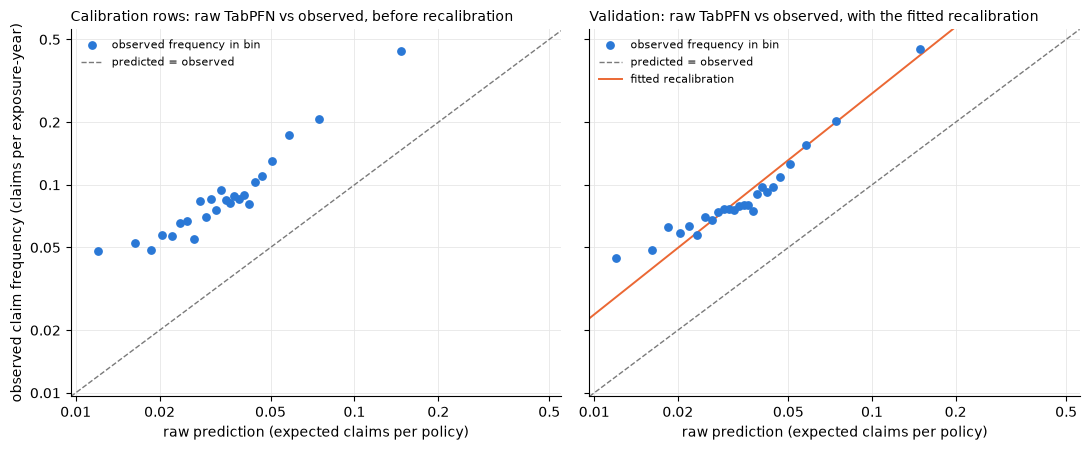

validation: observed / recalibrated by bin ranges 0.78 – 1.54; bins outside ±10%: 11 of 25


In [28]:
# ============================================================
# 5b. BEFORE AND AFTER RECALIBRATION: binned predicted vs observed claim frequency, log-log
# y on both panels: observed claim frequency = claims / exposure within the bin (claims per exposure-year)
# x left:  raw TabPFN prediction (expected claims per policy)     -> off the identity by design; the orange line is the fitted map
# x right: recalibrated frequency (claims per exposure-year)      -> should sit on the identity
# ============================================================
def freq_bins(pred, part, n_bins=25):
    """Equal-exposure bins of the prediction. Within each bin:
       pred   = exposure-weighted mean of the prediction
       actual = sum(ClaimNb) / sum(Exposure)          <- claim frequency, claims per exposure-year
       se     = sqrt(sum(ClaimNb)) / sum(Exposure)    <- Poisson standard error of that frequency"""
    d = pd.DataFrame({"pred": np.asarray(pred, dtype=float),
                      "y":    part.ClaimNb.values.astype(float),
                      "e":    part.Exposure.values.astype(float)}).sort_values("pred")
    d["bin"] = pd.cut(d.e.cumsum(), n_bins, labels=False)
    g = d.groupby("bin")
    out = pd.DataFrame({"pred":     g.apply(lambda b: np.average(b.pred, weights=b.e), include_groups=False),
                        "claims":   g.y.sum(),
                        "exposure": g.e.sum()})
    out["actual"] = out.claims / out.exposure
    out["se"]     = np.sqrt(out.claims) / out.exposure
    return out

def calibration_panel(ax, bins, title, xlabel, fit=None, ci=True):
    if ci:
        ax.errorbar(bins.pred, bins.actual, yerr=1.96 * bins.se, fmt="none", ecolor=BLUE, elinewidth=0.8, alpha=0.5)
    ax.scatter(bins.pred, bins.actual, s=28, color=BLUE, zorder=3, label="observed frequency in bin")
    lo = min(bins.pred.min(), bins.actual.min()) * 0.8
    hi = max(bins.pred.max(), bins.actual.max()) * 1.25
    ax.plot([lo, hi], [lo, hi], color=GREY, lw=1, ls="--", label="predicted = observed")
    if fit is not None:
        xs = np.geomspace(lo, hi, 200)
        ax.plot(xs, fit(xs), color=ORANGE, lw=1.4, label="fitted recalibration")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ticks = [t for t in [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1] if lo <= t <= hi]
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(plt.FixedLocator(ticks))
        axis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
        axis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel(xlabel); ax.set_title(title, fontsize=10, loc="left")
    ax.grid(True, color="#e6e6e6", lw=0.6); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# ---- bins: raw prediction on x for both panels ----
bins_cal = freq_bins(raw_cal, calib,      n_bins=25)   # calibration rows (the map was fitted here)
bins_val = freq_bins(raw_val, validation, n_bins=25)   # validation rows (the map has never seen these)

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
calibration_panel(axes[0], bins_cal, "Calibration rows: raw TabPFN vs observed, before recalibration",
                  "raw prediction (expected claims per policy)", ci=False)
calibration_panel(axes[1], bins_val, "Validation: raw TabPFN vs observed, with the fitted recalibration",
                  "raw prediction (expected claims per policy)", fit=lqm_freq, ci=False)
axes[0].set_ylabel("observed claim frequency (claims per exposure-year)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[1].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

# ---- the same check in numbers, now on validation ----
r = bins_val.actual / lqm_freq(bins_val.pred.values)
print(f"validation: observed / recalibrated by bin ranges {r.min():.2f} – {r.max():.2f}; "
      f"bins outside ±10%: {int((np.abs(r - 1) > 0.10).sum())} of {len(r)}")

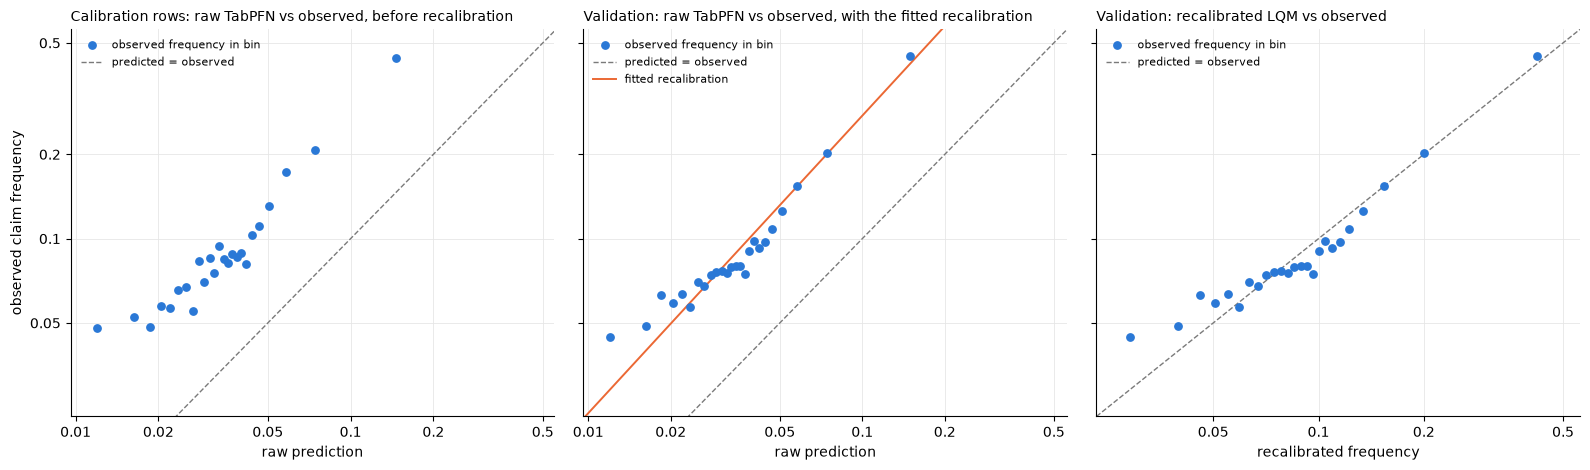

validation, recalibrated: observed / predicted by bin ranges 0.78 – 1.54; bins outside ±10%: 11 of 25


In [29]:
# ---- bins ----
bins_cal  = freq_bins(raw_cal,             calib,      n_bins=25)   # raw, calibration rows (the map was fitted here)
bins_val  = freq_bins(raw_val,             validation, n_bins=25)   # raw, validation rows (the map has never seen these)
bins_post = freq_bins(validation.lqm_freq, validation, n_bins=25)   # recalibrated, validation rows

# ---- plot ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
calibration_panel(axes[0], bins_cal,  "Calibration rows: raw TabPFN vs observed, before recalibration",
                  "raw prediction", ci=False)
calibration_panel(axes[1], bins_val,  "Validation: raw TabPFN vs observed, with the fitted recalibration",
                  "raw prediction", fit=lqm_freq, ci=False)
calibration_panel(axes[2], bins_post, "Validation: recalibrated LQM vs observed",
                  "recalibrated frequency", ci=False)
axes[0].set_ylabel("observed claim frequency")
for ax in axes:
    ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

r = bins_post.actual / bins_post.pred
print(f"validation, recalibrated: observed / predicted by bin ranges {r.min():.2f} – {r.max():.2f}; "
      f"bins outside ±10%: {int((np.abs(r - 1) > 0.10).sum())} of {len(r)}")

In [9]:
v = validation
top_lqm = v.lqm_freq >= v.lqm_freq.quantile(0.9)
top_glm = v.glm_freq >= v.glm_freq.quantile(0.9)
print(f"policies in both top deciles: {(top_lqm & top_glm).mean():.1%} of the book;  "
      f"LQM-only: {(top_lqm & ~top_glm).mean():.1%};  GLM-only: {(~top_lqm & top_glm).mean():.1%}")
for lab, mask in [("LQM top only", top_lqm & ~top_glm), ("GLM0 top only", ~top_lqm & top_glm), ("both", top_lqm & top_glm)]:
    s = v[mask]
    print(f"\n{lab}: {len(s)} policies, observed freq {s.ClaimNb.sum() / s.Exposure.sum():.4f}, "
          f"LQM pred {np.average(s.lqm_freq, weights=s.Exposure):.4f}, GLM0 pred {np.average(s.glm_freq, weights=s.Exposure):.4f}")
    print(s[["DrivAge", "VehAge", "BonusMalus", "VehPower", "Density"]].describe().loc[["25%", "50%", "75%"]].round(1).to_string())
    print("   top brands:", s.VehBrand.value_counts(normalize=True).head(3).round(2).to_dict(),
          "  area:", s.Area.value_counts(normalize=True).head(3).round(2).to_dict())

policies in both top deciles: 4.5% of the book;  LQM-only: 5.5%;  GLM-only: 5.5%

LQM top only: 9327 policies, observed freq 0.2204, LQM pred 0.2692, GLM0 pred 0.1288
     DrivAge  VehAge  BonusMalus  VehPower  Density
25%     36.0     3.0        61.0       5.0     91.0
50%     48.0     7.0        68.0       6.0    405.0
75%     58.0    11.0        90.0       7.0   1408.0
   top brands: {'B1': 0.3, 'B2': 0.28, 'B3': 0.1}   area: {'C': 0.26, 'D': 0.25, 'E': 0.2}

GLM0 top only: 9328 policies, observed freq 0.1570, LQM pred 0.1002, GLM0 pred 0.3046
     DrivAge  VehAge  BonusMalus  VehPower  Density
25%     34.0     0.0        50.0       5.0    151.8
50%     46.0     0.0        52.0       7.0    721.0
75%     56.0     0.0        85.0       8.0   3301.0
   top brands: {'B12': 0.46, 'B2': 0.15, 'B1': 0.15}   area: {'E': 0.27, 'C': 0.25, 'D': 0.23}

both: 7599 policies, observed freq 0.5149, LQM pred 0.3810, GLM0 pred 0.3453
     DrivAge  VehAge  BonusMalus  VehPower  Density
25%     30.0  

In [10]:
# ============================================================
# 5e. TABPFN REGRESSOR ON THE SAME TERMS, FOR COMPARISON
# Same context, same nine factors, no exposure input, target = claim count per policy;
# same Poisson recalibration with log-exposure offset on the same calibration rows.
# ============================================================
from tabpfn import TabPFNRegressor

_reg = None
def reg_model():
    global _reg
    if _reg is None:
        m = TabPFNRegressor(device="cuda", random_state=0, fit_mode="fit_with_cache", n_estimators=4,
                            categorical_features_indices=CAT_IDX)
        _reg = m.fit(lqm_inputs(ctx), ctx.ClaimNb.values.astype(float))       # count per policy, term averaged out
    return _reg

def reg_raw(part, name, chunk=5000):
    """Raw expected claims per policy from the regressor (mean of its predictive distribution). Cached on disk."""
    path = f"lqmreg_noexp_{name}.parquet"
    if os.path.exists(path):
        return pd.read_parquet(path).loc[part.index, "raw"].values
    X = lqm_inputs(part)
    r = np.concatenate([reg_model().predict(X.iloc[i:i + chunk]) for i in range(0, len(X), chunk)])
    pd.DataFrame({"raw": r}, index=part.index).to_parquet(path)
    return r

reg_cal = reg_raw(calib, "calib")
reg_val = reg_raw(validation, "validation")
print(f"regressor raw output: min {reg_val.min():.4f}, share <= 0: {(reg_val <= 0).mean():.2%}   "
      f"(clipped to 1e-4 before the log in the recalibration)")
reg_cal, reg_val = np.clip(reg_cal, 1e-4, None), np.clip(reg_val, 1e-4, None)

a_r, b_r, reg_freq = recalibrate(reg_cal)
print(f"regressor recalibration: frequency = exp({a_r:.3f} + {b_r:.3f} * log(raw))   "
      f"[raw total on calib was {(reg_cal * calib.Exposure.values).sum() / calib.ClaimNb.sum():.0%} of actual claims]")

validation["reg_raw"]  = reg_val
validation["reg_freq"] = reg_freq(reg_val)

print("\nvalidation scores:")
report("GLM0  (tutorial spec)",          validation.glm_freq.values, validation)
report("LQM   classifier (recalibrated)", validation.lqm_freq.values, validation)
report("LQM   regressor  (recalibrated)", validation.reg_freq.values, validation)
report("GBM   (ceiling)",                validation.gbm_freq.values, validation)

m, lo, hi = paired_bootstrap(validation.lqm_freq.values, validation.reg_freq.values, validation)
print(f"\nD2 gain of regressor over classifier: {m:+.2f} pp   95% interval [{lo:+.2f}, {hi:+.2f}]")
print(f"rank agreement between the two informants (Spearman): "
      f"{pd.Series(validation.lqm_freq.values).corr(pd.Series(validation.reg_freq.values), method='spearman'):.3f}")

print("\nby decile of regressor-predicted frequency:")
print(calibration_table(validation, "reg_freq", {"REG": "reg_freq", "LQM": "lqm_freq", "GLM0": "glm_freq"}).round(4).T)

for lab, mask in [("exposure < 0.25", validation.Exposure < 0.25), ("exposure >= 0.25", validation.Exposure >= 0.25)]:
    sub = validation[mask]
    print(f"\n{lab}: {len(sub)} policies")
    report("   LQM classifier", sub.lqm_freq.values, sub)
    report("   LQM regressor",  sub.reg_freq.values, sub)
    report("   GLM0",           sub.glm_freq.values, sub)

c:\Users\igode\Desktop\lqm\.venv\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


regressor raw output: min 0.0005, share <= 0: 0.00%   (clipped to 1e-4 before the log in the recalibration)
regressor recalibration: frequency = exp(0.857 + 0.709 * log(raw))   [raw total on calib was 13% of actual claims]

validation scores:
GLM0  (tutorial spec)              D2  4.92%   Gini 0.279   dev/yr 0.5908   dev/policy 0.3126   predicted claims   9037  (actual 8978)
LQM   classifier (recalibrated)    D2  6.53%   Gini 0.290   dev/yr 0.5808   dev/policy 0.3073   predicted claims   9097  (actual 8978)
LQM   regressor  (recalibrated)    D2  5.66%   Gini 0.292   dev/yr 0.5862   dev/policy 0.3101   predicted claims   9085  (actual 8978)
GBM   (ceiling)                    D2  8.15%   Gini 0.332   dev/yr 0.5707   dev/policy 0.3019   predicted claims   9035  (actual 8978)

D2 gain of regressor over classifier: -0.86 pp   95% interval [-1.11, -0.59]
rank agreement between the two informants (Spearman): 0.791

by decile of regressor-predicted frequency:
reg_freq                0         

In [12]:
print("\nvalidation scores:")
report("GLM0  (tutorial spec)",           validation.glm_freq.values, validation)
report("LQM   classifier raw",            validation.lqm_raw.values,  validation)
report("LQM   classifier (recalibrated)", validation.lqm_freq.values, validation)
report("LQM   regressor  raw",            validation.reg_raw.values,  validation)
report("LQM   regressor  (recalibrated)", validation.reg_freq.values, validation)
report("GBM   (ceiling)",                 validation.gbm_freq.values, validation)


validation scores:
GLM0  (tutorial spec)              D2  4.92%   Gini 0.279   dev/yr 0.5908   dev/policy 0.3126   predicted claims   9037  (actual 8978)
LQM   classifier raw               D2 -4.37%   Gini 0.290   dev/yr 0.6485   dev/policy 0.3431   predicted claims   3468  (actual 8978)
LQM   classifier (recalibrated)    D2  6.53%   Gini 0.290   dev/yr 0.5808   dev/policy 0.3073   predicted claims   9097  (actual 8978)
LQM   regressor  raw               D2 -32.89%   Gini 0.292   dev/yr 0.8257   dev/policy 0.4369   predicted claims   1181  (actual 8978)
LQM   regressor  (recalibrated)    D2  5.66%   Gini 0.292   dev/yr 0.5862   dev/policy 0.3101   predicted claims   9085  (actual 8978)
GBM   (ceiling)                    D2  8.15%   Gini 0.332   dev/yr 0.5707   dev/policy 0.3019   predicted claims   9035  (actual 8978)


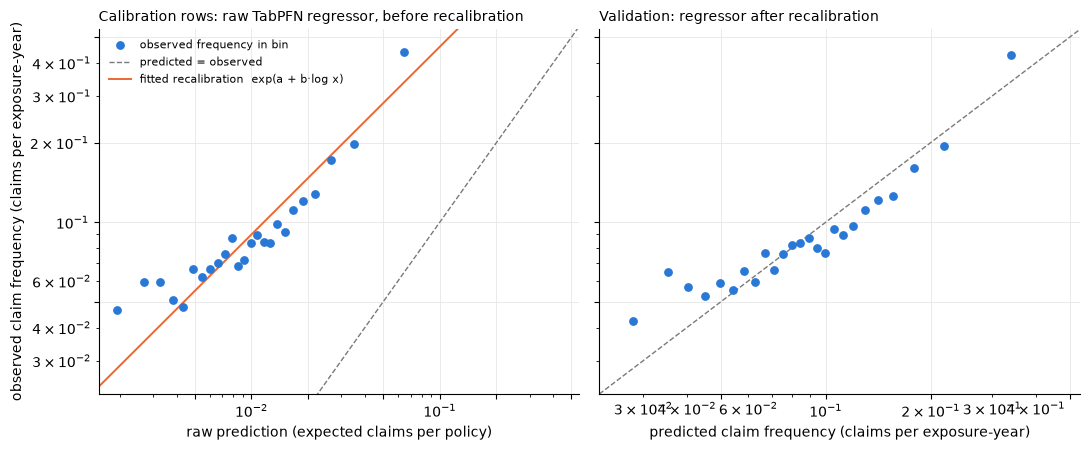

regressor, before: raw bins vs their own straight line — slope 0.557 (recalibration b = 0.709), log-residual sd 0.181, largest |residual| 0.543
regressor, after:  validation actual/predicted by bin ranges 0.77 – 1.84; bins outside ±10%: 18 of 25


In [13]:
bins_cal_r = freq_bins(reg_cal,               calib,      n_bins=25)   # before: x = raw per policy
bins_val_r = freq_bins(validation.reg_freq,   validation, n_bins=25)   # after:  x = recalibrated per exposure-year

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
calibration_panel(axes[0], bins_cal_r, "Calibration rows: raw TabPFN regressor, before recalibration",
                  "raw prediction (expected claims per policy)", fit=reg_freq, ci=False)
calibration_panel(axes[1], bins_val_r, "Validation: regressor after recalibration",
                  "predicted claim frequency (claims per exposure-year)", ci=False)
axes[0].set_ylabel("observed claim frequency (claims per exposure-year)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

lr    = np.polyfit(np.log(bins_cal_r.pred), np.log(bins_cal_r.actual), 1)
resid = np.log(bins_cal_r.actual) - np.polyval(lr, np.log(bins_cal_r.pred))
print(f"regressor, before: raw bins vs their own straight line — slope {lr[0]:.3f} (recalibration b = {b_r:.3f}), "
      f"log-residual sd {resid.std():.3f}, largest |residual| {np.abs(resid).max():.3f}")
r = bins_val_r.actual / bins_val_r.pred
print(f"regressor, after:  validation actual/predicted by bin ranges {r.min():.2f} – {r.max():.2f}; "
      f"bins outside ±10%: {int((np.abs(r - 1) > 0.10).sum())} of {len(r)}")

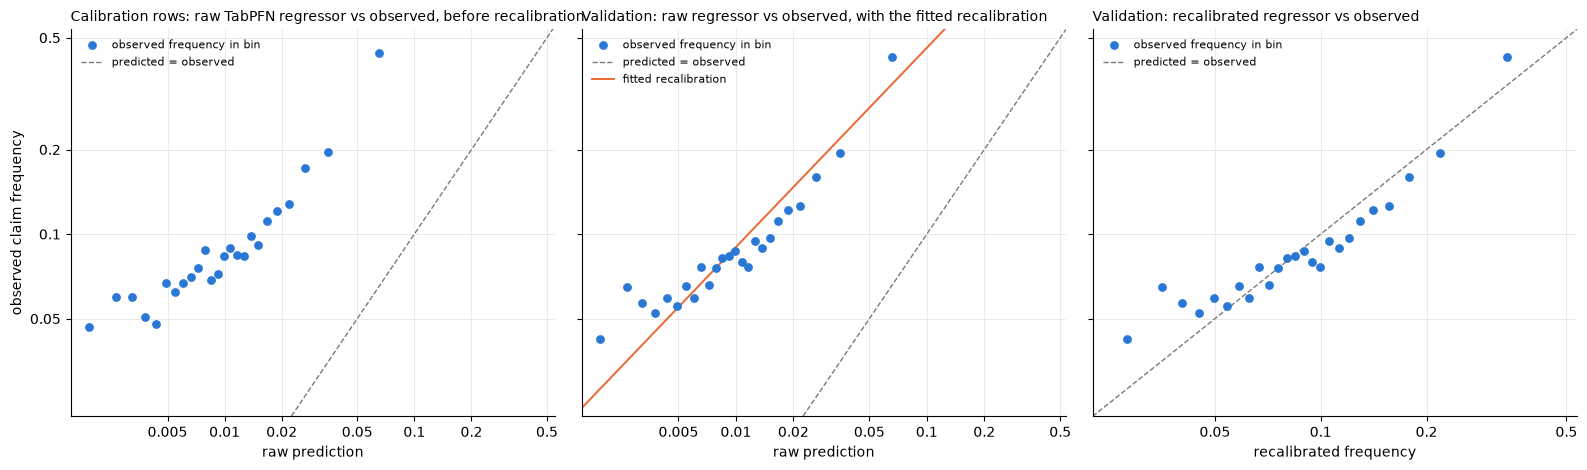

regressor, before: raw bins vs their own straight line — slope 0.557 (recalibration b = 0.709), log-residual sd 0.181, largest |residual| 0.543
regressor, after:  validation observed / predicted by bin ranges 0.77 – 1.84; bins outside ±10%: 18 of 25


In [31]:
bins_cal_r  = freq_bins(reg_cal,             calib,      n_bins=25)   # raw, calibration rows (the map was fitted here)
bins_val_r  = freq_bins(reg_val,             validation, n_bins=25)   # raw, validation rows
bins_post_r = freq_bins(validation.reg_freq, validation, n_bins=25)   # recalibrated, validation rows

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
calibration_panel(axes[0], bins_cal_r,  "Calibration rows: raw TabPFN regressor vs observed, before recalibration",
                  "raw prediction", ci=False)
calibration_panel(axes[1], bins_val_r,  "Validation: raw regressor vs observed, with the fitted recalibration",
                  "raw prediction", fit=reg_freq, ci=False)
calibration_panel(axes[2], bins_post_r, "Validation: recalibrated regressor vs observed",
                  "recalibrated frequency", ci=False)
axes[0].set_ylabel("observed claim frequency")
for ax in axes:
    ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

lr    = np.polyfit(np.log(bins_cal_r.pred), np.log(bins_cal_r.actual), 1)
resid = np.log(bins_cal_r.actual) - np.polyval(lr, np.log(bins_cal_r.pred))
print(f"regressor, before: raw bins vs their own straight line — slope {lr[0]:.3f} (recalibration b = {b_r:.3f}), "
      f"log-residual sd {resid.std():.3f}, largest |residual| {np.abs(resid).max():.3f}")
r = bins_post_r.actual / bins_post_r.pred
print(f"regressor, after:  validation observed / predicted by bin ranges {r.min():.2f} – {r.max():.2f}; "
      f"bins outside ±10%: {int((np.abs(r - 1) > 0.10).sum())} of {len(r)}")

In [14]:
for lab, raw in [("classifier", raw_cal), ("regressor", reg_cal)]:
    print(f"{lab:11s} raw expected claims per policy: predicted {raw.sum():.0f}  vs actual {calib.ClaimNb.sum():.0f}  "
          f"({raw.sum() / calib.ClaimNb.sum():.0%} of actual, same units)")

classifier  raw expected claims per policy: predicted 3178  vs actual 4288  (74% of actual, same units)
regressor   raw expected claims per policy: predicted 1113  vs actual 4288  (26% of actual, same units)


In [11]:
validation["ens_freq"] = np.sqrt(validation.lqm_freq * validation.reg_freq)     # geometric mean of the two frequencies
report("LQM   classifier",           validation.lqm_freq.values, validation)
report("LQM   regressor",            validation.reg_freq.values, validation)
report("LQM   classifier+regressor", validation.ens_freq.values, validation)
m, lo, hi = paired_bootstrap(validation.lqm_freq.values, validation.ens_freq.values, validation)
print(f"D2 gain of the average over the classifier: {m:+.2f} pp  [{lo:+.2f}, {hi:+.2f}]")

LQM   classifier                   D2  6.53%   Gini 0.290   dev/yr 0.5808   dev/policy 0.3073   predicted claims   9097  (actual 8978)
LQM   regressor                    D2  5.66%   Gini 0.292   dev/yr 0.5862   dev/policy 0.3101   predicted claims   9085  (actual 8978)
LQM   classifier+regressor         D2  6.60%   Gini 0.301   dev/yr 0.5804   dev/policy 0.3071   predicted claims   8952  (actual 8978)
D2 gain of the average over the classifier: +0.07 pp  [-0.06, +0.21]


y-axis: validation bins pool to 8978 claims / 89551 exposure-years = 0.1003  (validation overall 0.1003)
x-axis, left : raw per policy, exposure-weighted mean 0.0387 vs calib observed frequency 0.1014  (gap = level correction)
x-axis, right: recalibrated frequency, predicted claims 9097 vs actual 8978


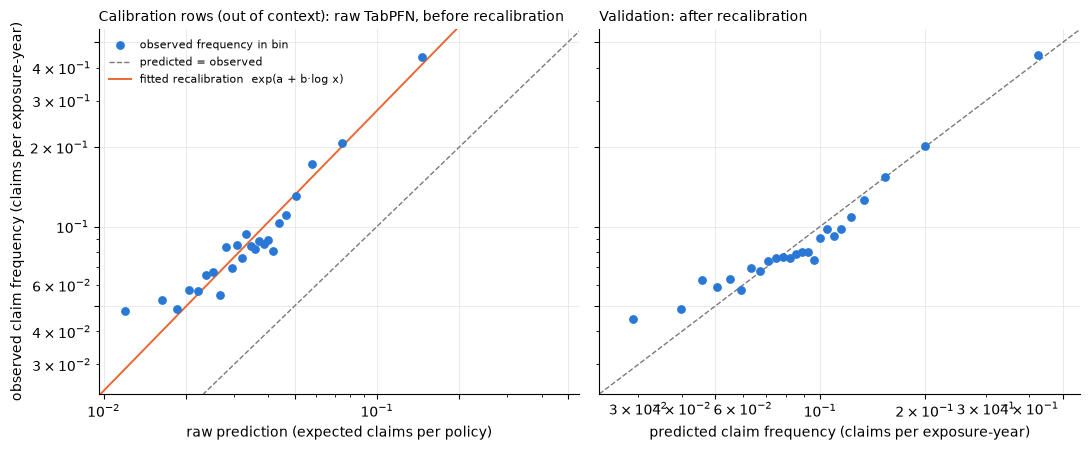


before: raw bins vs their own straight line — slope 0.924 (recalibration b = 1.062), log-residual sd 0.149, largest |residual| 0.354
after:  validation actual/predicted by bin ranges 0.78 – 1.54; bins outside ±10%: 11 of 25


In [ ]:
# ============================================================
# 5b. BEFORE AND AFTER RECALIBRATION: binned predicted vs observed claim frequency, log-log
# y on both panels: observed claim frequency = claims / exposure within the bin (claims per exposure-year)
# x left:  raw TabPFN prediction (expected claims per policy)     -> off the identity by design; the orange line is the fitted map
# x right: recalibrated frequency (claims per exposure-year)      -> should sit on the identity
# ============================================================
def freq_bins(pred, part, n_bins=25):
    """Equal-exposure bins of the prediction. Within each bin:
       pred   = exposure-weighted mean of the prediction
       actual = sum(ClaimNb) / sum(Exposure)          <- claim frequency, claims per exposure-year
       se     = sqrt(sum(ClaimNb)) / sum(Exposure)    <- Poisson standard error of that frequency"""
    d = pd.DataFrame({"pred": np.asarray(pred, dtype=float),
                      "y":    part.ClaimNb.values.astype(float),
                      "e":    part.Exposure.values.astype(float)}).sort_values("pred")
    d["bin"] = pd.cut(d.e.cumsum(), n_bins, labels=False)
    g = d.groupby("bin")
    out = pd.DataFrame({"pred":     g.apply(lambda b: np.average(b.pred, weights=b.e), include_groups=False),
                        "claims":   g.y.sum(),
                        "exposure": g.e.sum()})
    out["actual"] = out.claims / out.exposure
    out["se"]     = np.sqrt(out.claims) / out.exposure
    return out

def calibration_panel(ax, bins, title, xlabel, fit=None, ci=True):
    if ci:
        ax.errorbar(bins.pred, bins.actual, yerr=1.96 * bins.se, fmt="none", ecolor=BLUE, elinewidth=0.8, alpha=0.5)
    ax.scatter(bins.pred, bins.actual, s=28, color=BLUE, zorder=3, label="observed frequency in bin")
    lo = min(bins.pred.min(), bins.actual.min()) * 0.8
    hi = max(bins.pred.max(), bins.actual.max()) * 1.25
    ax.plot([lo, hi], [lo, hi], color=GREY, lw=1, ls="--", label="predicted = observed")
    if fit is not None:
        xs = np.geomspace(lo, hi, 200)
        ax.plot(xs, fit(xs), color=ORANGE, lw=1.4, label="fitted recalibration  exp(a + b·log x)")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ticks = [t for t in [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1] if lo <= t <= hi]
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(plt.FixedLocator(ticks))
        # axis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
        # axis.set_minor_locator(plt.NullLocator())
    ax.set_xlabel(xlabel); ax.set_title(title, fontsize=10, loc="left")
    ax.grid(True, color="#e6e6e6", lw=0.6); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# ---- bins ----
bins_cal = freq_bins(raw_cal,             calib,      n_bins=25)   # before: x = raw per policy
bins_val = freq_bins(validation.lqm_freq, validation, n_bins=25)   # after:  x = recalibrated per exposure-year

# ---- unit checks: y really is claims / exposure ----
assert np.isclose(bins_cal.claims.sum() / bins_cal.exposure.sum(), calib.ClaimNb.sum() / calib.Exposure.sum())
assert np.isclose(bins_val.claims.sum() / bins_val.exposure.sum(), validation.ClaimNb.sum() / validation.Exposure.sum())
print(f"y-axis: validation bins pool to {bins_val.claims.sum():.0f} claims / {bins_val.exposure.sum():.0f} exposure-years "
      f"= {bins_val.claims.sum() / bins_val.exposure.sum():.4f}  (validation overall {validation.ClaimNb.sum() / validation.Exposure.sum():.4f})")
print(f"x-axis, left : raw per policy, exposure-weighted mean {np.average(raw_cal, weights=calib.Exposure):.4f} "
      f"vs calib observed frequency {calib.ClaimNb.sum() / calib.Exposure.sum():.4f}  (gap = level correction)")
print(f"x-axis, right: recalibrated frequency, predicted claims {np.sum(validation.lqm_freq * validation.Exposure):.0f} "
      f"vs actual {validation.ClaimNb.sum():.0f}")

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
calibration_panel(axes[0], bins_cal, "Calibration rows (out of context): raw TabPFN, before recalibration",
                  "raw prediction (expected claims per policy)", fit=lqm_freq, ci=False)
calibration_panel(axes[1], bins_val, "Validation: after recalibration",
                  "predicted claim frequency (claims per exposure-year)", ci=False)
axes[0].set_ylabel("observed claim frequency (claims per exposure-year)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

# ---- the same check in numbers ----
lr    = np.polyfit(np.log(bins_cal.pred), np.log(bins_cal.actual), 1)
resid = np.log(bins_cal.actual) - np.polyval(lr, np.log(bins_cal.pred))
print(f"\nbefore: raw bins vs their own straight line — slope {lr[0]:.3f} (recalibration b = {b:.3f}), "
      f"log-residual sd {resid.std():.3f}, largest |residual| {np.abs(resid).max():.3f}")
r = bins_val.actual / bins_val.pred
print(f"after:  validation actual/predicted by bin ranges {r.min():.2f} – {r.max():.2f}; "
      f"bins outside ±10%: {int((np.abs(r - 1) > 0.10).sum())} of {len(r)}")

In [7]:
pd.set_option("display.width", 160)
for lab, bins in [("calibration rows: raw TabPFN (x = raw per policy)", bins_cal),
                  ("validation: recalibrated LQM (x = frequency per exposure-year)", bins_val)]:
    t = bins[["claims", "exposure", "pred", "actual"]].copy()
    t["actual/pred"] = t.actual / t.pred
    t.columns = ["claims", "exposure-years", "predicted (mean)", "observed freq = claims/exposure", "observed/predicted"]
    print(f"\n{lab}")
    print(t.round(4).to_string())


calibration rows: raw TabPFN (x = raw per policy)
     claims  exposure-years  predicted (mean)  observed freq = claims/exposure  observed/predicted
bin                                                                                               
0      81.0       1691.8563            0.0120                           0.0479              3.9945
1      89.0       1692.6898            0.0163                           0.0526              3.2267
2      82.0       1691.6808            0.0186                           0.0485              2.6071
3      97.0       1692.5297            0.0205                           0.0573              2.8002
4      96.0       1692.5488            0.0221                           0.0567              2.5696
5     111.0       1691.6343            0.0236                           0.0656              2.7769
6     114.0       1692.3650            0.0252                           0.0674              2.6779
7      93.0       1692.7125            0.0266             

In [6]:
# ============================================================
# 5c. RECALIBRATION: EVIDENCE AND CHECKS
# ============================================================
from scipy.stats import chi2

# (1) the offset form equals the "frequency target, exposure weight" form  ->  the offset is the division by exposure
x_cal = np.log(np.clip(raw_cal, 1e-9, None)).reshape(-1, 1)
g_rate = GeneralizedLinearRegressor(family="poisson", alpha=0).fit(x_cal, calib.ClaimNb / calib.Exposure,
                                                                   sample_weight=calib.Exposure)
print(f"(1) offset form a={a:.6f} b={b:.6f}   rate form a={g_rate.intercept_:.6f} b={g_rate.coef_[0]:.6f}")

# (2) the map is monotone, so the ranking is untouched
print(f"(2) validation Gini: raw {gini(validation.lqm_raw.values, validation):.4f}   "
      f"recalibrated {gini(validation.lqm_freq.values, validation):.4f}")

# (3) does the map generalise?  A/E by decile on the rows it was fitted on vs on validation
calib = calib.copy()
calib["lqm_freq"] = lqm_freq(raw_cal)
ae_cal = calibration_table(calib,      "lqm_freq", {"LQM": "lqm_freq"})["A/LQM"]
ae_val = calibration_table(validation, "lqm_freq", {"LQM": "lqm_freq"})["A/LQM"]
print("(3) A/E by decile of recalibrated frequency:")
print(pd.DataFrame({"calibration rows (in-sample)": ae_cal, "validation (out-of-sample)": ae_val}).round(3).T)

# (4) adequacy of the two-parameter map: likelihood-ratio test against a quadratic in log(raw), on the calibration rows
def count_dev_total(mu, part):
    return mean_poisson_deviance(part.ClaimNb.values, np.clip(mu, 1e-9, None)) * len(part)
mu_lin  = lqm_freq(raw_cal) * calib.Exposure.values
g_quad  = GeneralizedLinearRegressor(family="poisson", alpha=0).fit(np.column_stack([x_cal, x_cal**2]), calib.ClaimNb,
                                                                    offset=np.log(calib.Exposure))
mu_quad = g_quad.predict(np.column_stack([x_cal, x_cal**2]), offset=np.log(calib.Exposure))
D_lin, D_quad = count_dev_total(mu_lin, calib), count_dev_total(mu_quad, calib)
lr_stat = D_lin - D_quad
print(f"(4) calibration rows: deviance linear {D_lin:.1f}, quadratic {D_quad:.1f}, "
      f"LR statistic {lr_stat:.1f} on 1 df, p = {chi2.sf(lr_stat, 1):.3g}")

# (5) out-of-sample: what the extra term would have been worth on validation (Gini unchanged by construction)
z_val = np.log(np.clip(raw_val, 1e-9, None))
quad_val = g_quad.predict(np.column_stack([z_val, z_val**2]), offset=np.zeros(len(z_val)))
m, lo, hi = paired_bootstrap(validation.lqm_freq.values, quad_val, validation)
print(f"(5) validation D2: linear {d2(validation.lqm_freq.values, validation):.2%}, quadratic {d2(quad_val, validation):.2%}; "
      f"gain {m:+.2f} pp [{lo:+.2f}, {hi:+.2f}]   (reported for completeness; the linear map is retained)")

(1) offset form a=1.154521 b=1.062243   rate form a=1.154521 b=1.062243
(2) validation Gini: raw 0.2903   recalibrated 0.2903
(3) A/E by decile of recalibrated frequency:
lqm_freq                          0      1      2      3      4      5      6  \
calibration rows (in-sample)  1.488  1.063  1.091  0.983  0.991  1.026  0.860   
validation (out-of-sample)    1.379  1.238  1.077  1.045  0.948  0.921  0.881   

lqm_freq                          7      8      9  
calibration rows (in-sample)  0.862  0.990  1.052  
validation (out-of-sample)    0.860  0.935  1.044  
(4) calibration rows: deviance linear 24852.8, quadratic 24844.9, LR statistic 8.0 on 1 df, p = 0.00476
(5) validation D2: linear 6.53%, quadratic 6.59%; gain +0.05 pp [+0.02, +0.09]   (reported for completeness; the linear map is retained)
